<div class='alert alert-block alert-info"'>
<h1> Simulation study :</h1>

<h4> Variable selection and estimation in a joint model of logitic longitudinal data and survival data </h4>
</div>

In [37]:
import jax.numpy as jnp

from sdg4varselect.models import WeibullCoxJM, logisticMEM
from sdg4varselect.outputs import TestResults
import sdg4varselect.plot as sdgplt

sdgplt.FIGSIZE = 15


def read(n, p, c, s=2):
    """read files results for n and p as parameter"""
    model = WeibullCoxJM(logisticMEM(N=n, J=5), P=p, alpha_scale=0.001, a=800, b=10)
    config = {"N": n, "J": 5, "P": p, "C": c}
    return TestResults.load(model, "files", f"C{c}_S{s}"), config


def read_multi_files(N, P, C, S=0):
    if len(N) == 1 and len(P) == 1 and len(C) == 1:
        out = [read(N[0], P[0], C[0], s=S)]
    elif len(N) == 1:
        out = [read(N[0], p, C[0], s=S) for p in P]
    elif len(P) == 1:
        out = [read(n, P[0], C[0], s=S) for n in N]
    else:
        out = [read(N[0], P[0], c, s=S) for c in C]

    return TestResults([o[0] for o in out], [o[1] for o in out])

In [38]:
def boxplot(ax, dt, **kwargs):
    bp = ax.boxplot(dt, patch_artist=True, **kwargs)

    for patch in bp["boxes"]:
        patch.set(facecolor=f"w")

    for median in bp["medians"]:
        median.set_color("black")

    return ax

In this section, we propose to study the performance of the procedure we have just presented. First of all, we want to show numerically the consistency of the estimator (ref{eq:penalized_estimator}) by studying 4 scenarios, varying the number of individuals observed. Then we'll demonstrate the method's ability to select variables by varying the number of covariates in the initial model. And finally with 3 relevant scenarios we will study the effect of censorship on the estimation procedure. This simulation study is conducted in the case of joint modeling for longitudinal logistic data, and a result for the pharmakokinetik model will also be presented in the end. In each scenario we generate independent data set and each time we fit the ref{eq:joint} model using the ref{algo:SPG-fim} routine described above (ref{algo:metho}).

Before anything else, to compare the next results of different scenarios, we look at the estimation error. We consider separately the relative root mean square errors $rrmse$ of the high dimensional parameters $\beta \in \mathbb R^p$ and of the low dimensional parameters, denotes by $\nu \in \mathbb R^d$ :
        
$$rrmse (\beta)  = \sqrt{\frac {||\beta -\hat\beta||^2}{p ||\beta||^2} } ~;~ rrmse (\nu)  = \sqrt{\frac 1d \sum_{i=1}^d  \frac {(\nu_i -\hat\nu_i)^2}{\nu_i^2 } }$$

# Logistic Joint-Model Specification

We first consider the joint model defined \ref{eq:joint} with the classical logistic function for the non-linear mixed effects model, defined by :

$$
    m: t \mapsto \dfrac{Z_1}{1 + \exp\left(\dfrac{Z_2-t}{Z_3}\right)},
$$

Where $Z_1$ represents the asymptotical maximum value of the curve, $Z_2$ represents the value of the sigmoid's midpoint, and $Z_3$ represents the logistic growth rate. 
We model for each individual $i$ the corresponding individual parameter $Z_i\in \mathbb R^3$ through a Gaussian random variable with expectation $\mu  \in \mathbb R^3$ and a diagonal variance $\Gamma=diag(\gamma_1^2,\gamma_2^2,0)$ meaning that the third parameter $\mu_3$ is modeled as a fixed effect. 

We consider a fixed Weibull baseline defined as $h_{a,b}(t)= b a^{-b} t^{b-1}$, where $a=80$ and $b=35$ are fixed (i.e. not estimated) in the simulation study. We focus in this simulation study on the selection of variables and on the inference  of the parameters of the mixed-effect model as well as  $\alpha$ the multiplicative parameter of the Cox model.

## Simulation setup

We generated 20 data set according to the joint model presented previously in Equation ref{eq:joint}. For each different value of $p$, we  choose the vector $\beta$ such that the first four components are equal to $(-2,-1,1,2)$ and the rest are equal to zero. Additionally, we generate the matrix of covariates $U$ with $N$ rows and $p$ columns, following a uniform distribution $U_{i,l} \sim \mathcal U([-1,1]) ; ~\forall i \in { 1, ..., N}, l\in{1,..., p}$. Afterwards, we renormalize all the matrix columns to obtain centered data. All the parameter values are detailed in the table ref{tab:truevalues} below.

In [39]:
myModel = WeibullCoxJM(logisticMEM(N=1000, J=5), P=5, alpha_scale=0.001, a=800, b=10)

p_star = myModel.new_params(
    mean_latent={"mu1": 200, "mu2": 500},
    mu3=150,
    cov_latent=jnp.diag(jnp.array([40, 100])),
    var_residual=100,
    alpha=0.005,
    beta=jnp.concatenate(  # jnp.zeros(shape=(myModel.P,)),  #
        [jnp.array([-2, -3, 3, 2]), jnp.zeros(shape=(myModel.P - 4,))]
    ),
)
print(str(p_star))  # .replace(", dtype=float64),", "),\n\t  "))

myModel = WeibullCoxJM(logisticMEM(N=1000, J=5), P=5000, alpha_scale=0.001, a=800, b=10)
p_star = myModel.new_params(
    mean_latent={"mu1": 200, "mu2": 500},
    mu3=150,
    cov_latent=jnp.diag(jnp.array([40, 100])),
    var_residual=100,
    alpha=0.005,
    beta=jnp.concatenate(  # jnp.zeros(shape=(myModel.P,)),  #
        [jnp.array([-2, -3, 3, 2]), jnp.zeros(shape=(myModel.P - 4,))]
    ),
)
p_star = myModel.hstack_params(p_star)

Parameters(mean_latent=Parameters(mu1=Array(200., dtype=float64), mu2=Array(500., dtype=float64)), mu3=Array(150., dtype=float64), cov_latent=Array([[ 40.,   0.],
       [  0., 100.]], dtype=float64), var_residual=Array(100., dtype=float64), alpha=Array(0.005, dtype=float64), beta=Array([-2., -3.,  3.,  2.,  0.], dtype=float64))


## Consistancy of $\hat\theta_{MLE}$

In this part, we aim to show the numerical consistance of the proposed estimator ref{eq:penalized_estimator}, thus we focus on four scenarios where the number of individuals observed is increasing : $N\in\{50,100,200,300\}$ when the number of covariates $p = 200$ and the number of longitudinal observations $J = 5$ are fixed. 

In [40]:
# results = read_multi_files(N=(100,), P=(100,), C=(0,), S=3)
# results = read_multi_files(N=(1000,), P=(5,), C=(0,), S="0")  # "(1, 20)")
results = read_multi_files(N=(100,), P=(200,), C=(0,), S="(1, 67)")

params_names = myModel.params_names

theta = jnp.array(results.last_theta)
print(theta.shape)

files/WCoxMemJM_N100_J5_P200_C0_S(1, 67) LOADED !
(1, 36, 3, 207)


In [41]:
results.total_number_res

1620

In [42]:
# chrono = jnp.array([[res.chrono.total_seconds() for res in reg] for reg in results[0]])
results.chrono.total_seconds() / results.total_number_res

9431.393554469136

The following graphe show the estimations for each parameter for the four scenarios

In [43]:
theta.shape

(1, 36, 3, 207)

IndexError: list index out of range

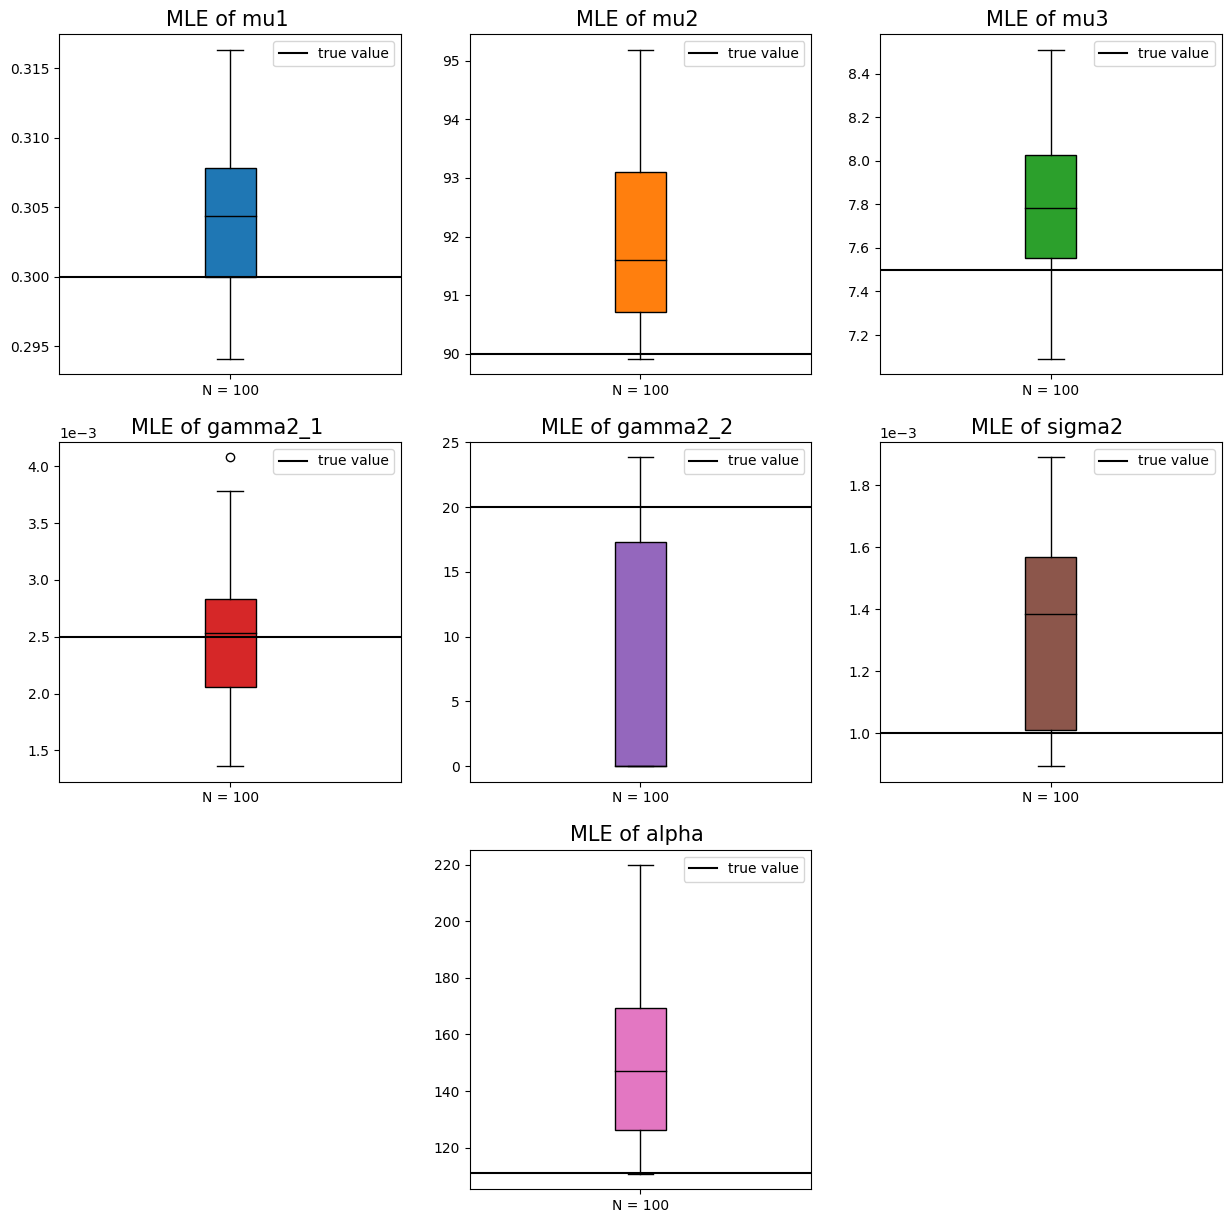

In [35]:
theta = jnp.array(results.last_theta)
scenarios_labels = results.get_scenarios_labels("N")


fig = sdgplt.figure()
id = [1, 2, 3, 4, 5, 6, 7, 8, 9]

id = [1, 2, 3, 4, 5, 6, 8]
p_star = [0.3, 90, 7.5, 2.5e-3, 20, 1e-3, 111.11]
params_names = ["mu1", "mu2", "mu3", "gamma2_1", "gamma2_2", "sigma2", "alpha"]

for i in range(9):
    ax = fig.add_subplot(3, 3, id[i])
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))

    bp = ax.boxplot(theta[:, :, -1, i][0], patch_artist=True, labels=scenarios_labels)

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(y=p_star[i], color="k", label="true value")

    ax.legend()
    ax.set_title(f"MLE of {params_names[i]} ", fontsize=15)


fig.set_figheight(10)
fig.set_figwidth(15)

IndexError: tuple index out of range

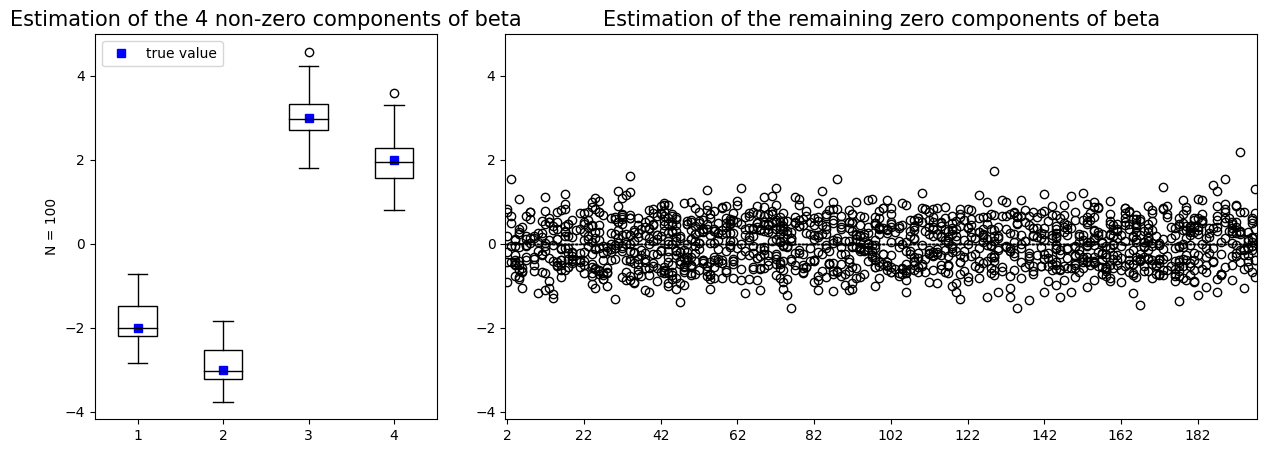

In [49]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

params_star_HD = p_star[9:]
import numpy as np

theta = np.array(results.last_theta)[:, :, :, 7:]
# theta = np.concatenate((thetax, np.zeros((1, 10, 3, 90))), axis=3)

# id = np.random.choice([i for i in range(100 - 4)], size=100 - 4, replace=False)
# theta[:, :, :, 4:] = theta[:, :, :, 4:][:, :, :, id]

G = GridSpec(len(results), 3)
fig = sdgplt.figure()

n_method = 2

P_max = theta.shape[3]
xticks = jnp.arange(0, P_max) + 1
for i in range(len(results)):
    ax = plt.subplot(G[i, 0])
    # print(theta[i][:, n_method, :4].T)

    ax = boxplot(ax, theta[i][:, n_method, :4])
    ax.plot(xticks[:4], params_star_HD[:4], "bs", label="true value")

    ax.legend()
    ax.set_ylabel(scenarios_labels[i])
    # == == == == #
    ax = plt.subplot(G[i, 1:], sharey=ax)
    ax = boxplot(ax, theta[i][:, n_method, 4:])
    xticks_nonzero = jnp.arange(4, P_max, step=P_max // 10) - 3
    ax.set_xticks(xticks_nonzero, xticks[xticks_nonzero])

ax = plt.subplot(G[0, 0])
ax.set_title(f"Estimation of the 4 non-zero components of beta", fontsize=15)
ax = plt.subplot(G[0, 1:], sharey=ax)
ax.set_title(f"Estimation of the remaining zero components of beta", fontsize=15)


fig.set_figheight(5)
fig.set_figwidth(15)

## Variable selection capacity

We now want to demonstrate our method's ability to perform variable selection. We define the following scenarios, with $N=100$ and $J=5$ fixed, we set the number of covariates increasing $P\in\{50,100,200,250,300,350,600, 800, 1000\}$.

In [ ]:
P = (5, 6, 10)
results = read_multi_files(N=(100,), P=P, C=(0,), S=3)

model = create_logistic_weibull_jm(N=100, J=5, P=max(P))

params_star = jnp.hstack(get_params_star(model))
params_names = model.params_names

In [ ]:
theta = jnp.array(
    [[res[-1][: model.DIM_LD] for res in test] for test in results.last_theta]
)
scenarios_labels = results.get_scenarios_labels("P")

fig = sdgplt.figure()
for i in range(7):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))
    bp = ax.boxplot(theta[:, i], patch_artist=True, labels=scenarios_labels)

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(y=params_star[i], color="k", label="true value")

    ax.legend()
    ax.set_title(f"EMV of {params_names[i]} ")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

params_star_HD = params_star[model.DIM_LD :] != 0

theta = jnp.array(
    jnp.array(results.last_theta)[:, :, :, model.DIM_LD :] != 0, dtype=jnp.float64
)

correct_model = jnp.array([params_star_HD == t for t in theta[0, :, -1, :]]).mean(
    axis=1
)

correct_model_sum = (
    jnp.array(
        [
            jnp.array(correct_model == 1).sum(),
            jnp.logical_and(0.9 <= correct_model, correct_model < 1).sum(),
            jnp.array(correct_model < 0.9).sum(),
        ]
    )
    / correct_model.shape[0]
)

labels = ["Exact", "Almost Exact", "Over-selection"]
hatchs = ["", "/", "*"]

fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
for i in range(correct_model_sum.shape[0]):
    ax.bar(
        scenarios_labels,
        correct_model_sum[i],
        label=labels[i],
        bottom=np.sum(correct_model_sum[:i], axis=0),
        width=0.1,
        hatch=hatchs[i],
    )


ax.legend()


fig.set_figheight(5)
fig.set_figwidth(5)

In [55]:
theta.shape[1]

(36, 200)

In [68]:
p_star[9:].shape

(5000,)

In [67]:
params_star_HD.shape

(191,)

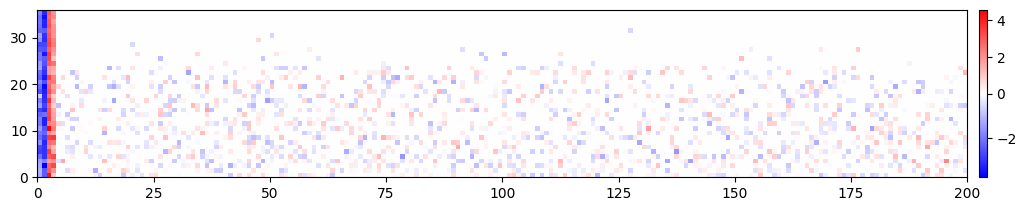

In [69]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

theta = jnp.array(
    [jnp.array([(res[-1][7:]) for res in test]) for test in results.last_theta]
)[0]

params_star_HD = p_star[9 : 9 + theta.shape[1]] != 0
correct_model = jnp.array([params_star_HD == t for t in theta]).mean(axis=1)

correct_model_sum = (
    jnp.array(
        [
            jnp.array(correct_model == 1).sum(),
            jnp.logical_and(0.9 <= correct_model, correct_model < 1).sum(),
            jnp.array(correct_model < 0.9).sum(),
        ]
    )
    / correct_model.shape[0]
)


fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)


def meshgrid(ax, dt):
    x_abs = 0.5 + np.arange(dt.shape[1])
    y_ord = 0.5 + np.arange(dt.shape[0])
    x, y = np.meshgrid(x_abs, y_ord)

    vmin = dt.min() if dt.min() < 0 else -0.001
    vmax = dt.max() if dt.max() > 0 else 0.0001

    colormesh = ax.pcolormesh(
        x,
        y,
        dt,
        cmap=plt.colormaps["bwr"],
        norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
    )

    ax.set_aspect("equal")

    # cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
    cb = fig.colorbar(colormesh, ax=ax)  # , location="right")

    return ax, cb


ax, cb = meshgrid(ax, theta[np.argsort(correct_model), :])
cb_pos = cb.ax.get_position()
ax_pos = ax.get_position()
cb.ax.set_position([ax_pos.xmax * 1.01, ax_pos.ymin, ax_pos.width, ax_pos.height])

In [ ]:
correct_model

In [ ]:
from matplotlib.gridspec import GridSpec

G = GridSpec(1, 5)
fig = sdgplt.figure()


x_abs = 0.5 + np.arange(theta.shape[1])
y_ord = 0.5 + np.arange(theta.shape[0])
x, y = np.meshgrid(x_abs, y_ord)

ax = sdgplt.plt.subplot(G[0, 0])
ax.pcolormesh(
    x,
    y,
    theta,
    cmap=plt.colormaps["bwr"],
    norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
)

x_abs = 0.5 + np.arange(1)
y_ord = 0.5 + np.arange(correct_model.shape[0])
x, y = np.meshgrid(x_abs, y_ord)


ax = sdgplt.plt.subplot(G[0, 1])
ax.pcolormesh(
    x,
    y,
    correct_model,
    cmap=plt.colormaps["bwr"],
    norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

theta = [
    jnp.array([(res[-1][model.DIM_LD :] != 0).mean() for res in test])
    for test in results.last_theta
]


fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
bp = ax.boxplot(theta, patch_artist=True, labels=scenarios_labels)

ax.set_title(f"Percentage of selected components")

In [ ]:
fig = sdgplt.figure()

for i in range(len(results)):
    for j in range(2):
        ax = fig.add_subplot(len(results), 4, 1 + 4 * i + j)
        ax.set_xscale("log")

        ax.plot(
            lbd_set, [res.theta[-1, 7:] for res in results[i][j].regularization_path]
        )

        ax_bic = ax.twinx()
        ax_bic.plot(
            lbd_set,
            results[i][j].bic,
            color="k",
            linewidth=2,
            linestyle="--",
            label="BIC",
        )

        id_min = jnp.nanargmin(results[i][j].bic)
        ax.axvline(x=lbd_set[id_min], color="b", linewidth=2, linestyle="--")

        id_min = jnp.nanargmax(results[i][j].bic[1:] - results[i][j].bic[:-1])
        ax.axvline(x=lbd_set[id_min], color="g", linewidth=2, linestyle="--")

    for j in range(2):
        ax = fig.add_subplot(len(results), 4, 1 + 2 + 4 * i + j)
        ax.set_xscale("log")

        ax.plot(
            lbd_set, [res.theta[-1, :7] for res in results[i][j].regularization_path]
        )

In [ ]:
i = 2
print(P[i])
j = 1
from sdg4varselect.algo import eBIC, BIC

multi_likelihood = jnp.array(
    [res.likelihood for res in results[i][j].regularization_path]
)
multi_theta_HD = jnp.array(
    [res.theta[-1, 7:] for res in results[i][j].regularization_path]
)

bic = BIC(multi_theta_HD, multi_likelihood, model.N)
ebic = eBIC(multi_theta_HD, multi_likelihood, model.N)


def BIC(theta_HD, log_likelihood, n, k_add=0):
    k = (theta_HD != 0).sum(axis=1)
    assert k.shape == log_likelihood.shape

    return -2 * log_likelihood + (k + k_add) * jnp.log(n)


bicJ = BIC(multi_theta_HD, multi_likelihood, model.N * (model.J + 1))

bic5 = BIC(multi_theta_HD, multi_likelihood, model.N * (model.J + 1), k_add=5)

bic6 = BIC(multi_theta_HD, multi_likelihood, model.N * (model.J + 1), k_add=6)

bic7 = BIC(multi_theta_HD, multi_likelihood, model.N * (model.J + 1), k_add=7)

fig = sdgplt.figure()
ax = fig.add_subplot(2, 1, 1)
ax.set_xscale("log")
ax.plot(lbd_set, multi_theta_HD)
ax.set_title(f"Regularization path for N={model.N},P={P[i]},J={model.J}")

ax = fig.add_subplot(2, 1, 2)
ax.set_xscale("log")

ax.plot(lbd_set, bic, color=f"C{5}", linewidth=2, linestyle="--", label="BIC N")
ax.plot(lbd_set, ebic, color=f"C{0}", linewidth=2, linestyle="--", label="eBIC")
ax.plot(lbd_set, bicJ, color=f"C{1}", linewidth=2, linestyle="--", label="bic (J+1)*N")
ax.plot(lbd_set, bic5, color=f"C{2}", linewidth=2, linestyle="--", label="bic5")
ax.plot(lbd_set, bic6, color=f"C{3}", linewidth=2, linestyle="--", label="bic6")
ax.plot(lbd_set, bic7, color=f"C{4}", linewidth=2, linestyle="--", label="bic7")


ax.set_title("Different criteria for the selection of the regularization parameter")
ax.legend()

## Censoring Effect

We now want to demonstrate our method's ability to perform variable selection. We define the following scenarios, with $N=100$ and $J=5$ fixed, we set the number of covariates increasing $P\in\{50,100,200,250,300,350,600, 800, 1000\}$.

In [ ]:
results, lbd_set, _, _, scenarios_labels = read_multi_files(N=(50,), P=(8,), S=2)
model = Logistic_JM(N=50, J=5, DIM_HD=8)

In [ ]:
results[i][j].regularization_path[0].theta[-1].shape